<a href="https://colab.research.google.com/github/jennmcwilliams2-tech/Assignmentone/blob/main/Term_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Data Manuipluation and Analysis

import pandas
import numpy as np

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
#Visulization Libraires
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

In [ ]:
#Machine Learning Libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score,
  recall_score, f1_score, confusion_matrix, classification_report,
  roc_curve , roc_auc_score
  )

In [ ]:
#Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

In [ ]:
#Hyperparameter Training
!pip install optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_contour

#Model Persistence
import joblib
import pickle

#File Handling
import os
import urllib.request

# Warnings
import warnings
warnings.filterwarnings('ignore')

#Set randon seed for reproducibility
np.random.seed(0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.7 MB/s eta 0:00:00


In [ ]:
#Load the Synthetic Customer Churn from Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import pandas

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dhrubangtalukdar/telco-customer-churn-data",
  "synthetic_customer_churn_100k.csv"
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)


100%|██████████| 5.88M/5.88M [00:00<00:00, 9.80MB/s]


Exploratory Data Analysis (EDA)

In [ ]:
#Display Data Set Info
print ("df.info")
print ("="*50)
df.info()


df.info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [ ]:
#Defining the Columns
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
#Statistical Summary
print("Statistical Summary")
print("="*50)
df.describe()

Statistical Summary


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


In [ ]:
df.describe(include='all')

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
count,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000,100000,100000.000000,100000
unique,NaN,NaN,3,NaN,NaN,3,4,NaN,2
top,NaN,NaN,Female,NaN,NaN,Month-to-month,Electronic check,NaN,No
freq,NaN,NaN,48256,NaN,NaN,54915,34892,NaN,66856
mean,50000.500000,49.027240,NaN,36.527090,79.974933,NaN,NaN,2926.140256,NaN
std,28867.657797,18.177862,NaN,20.789552,40.491961,NaN,NaN,2388.163672,NaN
min,1.000000,18.000000,NaN,1.000000,10.000000,NaN,NaN,-118.430000,NaN
25%,25000.750000,33.000000,NaN,18.000000,44.720000,NaN,NaN,963.667500,NaN
50%,50000.500000,49.000000,NaN,37.000000,80.000000,NaN,NaN,2268.060000,NaN
75%,75000.250000,65.000000,NaN,54.000000,115.050000,NaN,NaN,4394.327500,NaN


In [ ]:
def coerce_columns_to_numeric(df, column_list):
    df[column_list] = df[column_list].apply(pandas.to_numeric, errors='coerce')
    return df

In [ ]:
print("Dataset shape:",df.shape)
df.head()


Dataset shape: (100000, 9)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [ ]:
df_hap_na=df[df.isnull().any(axis=1)]
df_hap_na.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn



Feature Engineering

In [ ]:
#Check for Missing Values
print("Missing Values")
print("="*50)
Missing_Values = df.isnull().sum()
Missing_percentage = (Missing_Values/len(df))*100


missing_df = pd.DataFrame({'Missing_Values':Missing_Values, 'Missing_percentage':Missing_percentage})

# Filter and sort missing_df
missing_df = missing_df[missing_df['Missing_Values'] > 0].sort_values(
    'Missing_Values', ascending=False
)
print (missing_df)

Missing Values
Empty DataFrame
Columns: [Missing_Values, Missing_percentage]
Index: []


**SELECT FEATURES FOR MODELING**

In [ ]:
#Churn Rate
print("Target Variable Distribtuion(Churn):")
print("="*50)
df['Churn'].value_counts()
print("\nChurn Rate:")
print("="*50)
print(df['Churn'].value_counts(normalize=True)*100)

churn_rate = df['Churn'].value_counts(normalize=True).get('Yes', 0) * 100
print(f"\nChurn Rate: {churn_rate:.2f}%")

Target Variable Distribtuion(Churn):

Churn Rate:
Churn
No     66.856
Yes    33.144
Name: proportion, dtype: float64

Churn Rate: 33.14%


**Interactive Visulatization with Plot**ly

In [ ]:
#Interactive pie chart for churn distribution
churn_rate = df['Churn'].value_counts(normalize=True).get('Yes', 0) * 100
labels=['Customer','Churned']
values=[100-churn_rate,churn_rate]
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig
colours=['#FF6B6B', '#4ECDC4']

fig.update_layout(
  title="Telco Churn Distribtuion",
  title_font_size=20,
  height=500,
  width=500,
  )
fig.show()


Churn Rate by Gender:
Gender
Female    32.847729
Male      33.385649
Other     33.838767
Name: Churn, dtype: float64


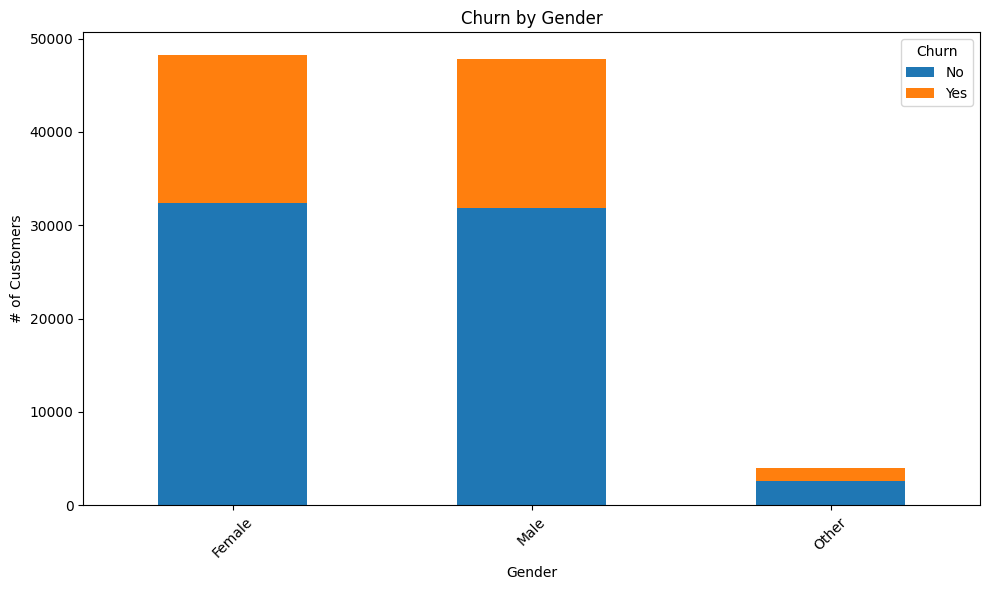

In [ ]:
#Churn by Gender

tenure_churn = df.groupby(['Gender', 'Churn']).size().reset_index(name='Count')

# Create the pivot table for plotting
tenure_churn_pivot = tenure_churn.pivot(index='Gender', columns='Churn', values='Count').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
tenure_churn_pivot.plot(kind='bar', stacked=True, ax=ax)
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('# of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()

fig.show()

#Show churn rate by gender
print("Churn Rate by Gender:")
print(df.groupby('Gender')['Churn'].apply(lambda x: (x == 'Yes').mean()) * 100)

In [ ]:
#If p< 0.05, data is likely not nofmrally distributed,
#my p value is less than 0.05 distribution is normal

from scipy.stats import shapiro
stat,p=shapiro(df['MonthlyCharges'])
print ('Shapiro_Wilk Test p-value', p)

Shapiro_Wilk Test p-value 9.898524963013285e-92


In [ ]:
#Correlation Heatmap

#Prepare the numerical values
numberical_coi=df.select_dtypes(include=['int64','float64'])
corr_df =df[numberical_coi.columns]
corr_matrix = corr_df.corr()

fig=px.imshow(corr_matrix,
              text_auto=True,
              title="Churn Correlation Heatmap"
              )
fig.show()

**Pre-Processing - One hot Encoding**

In [ ]:
import pandas as pd

# List of columns to be one-hot encoded
categorical_cols = ['Gender', 'Contract', 'PaymentMethod', 'Churn']

# Perform one-hot encoding for all specified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)

# Display the first 5 records of the new DataFrame with all encoded columns
print("DataFrame after One-Hot Encoding for 'Gender', 'Contract', 'PaymentMethod', and 'Churn':")
display(df_encoded.head())

DataFrame after One-Hot Encoding for 'Gender', 'Contract', 'PaymentMethod', and 'Churn':


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Female,Gender_Male,Gender_Other,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,1,56,68,147.58,10052.03,1,0,0,0,0,1,1,0,0,0,1,0
1,2,69,32,22.54,686.78,0,1,0,1,0,0,0,0,0,1,1,0
2,3,46,10,52.47,537.88,1,0,0,0,1,0,0,0,1,0,1,0
3,4,32,22,109.67,2390.04,0,1,0,1,0,0,0,0,0,1,0,1
4,5,60,54,130.98,7081.28,1,0,0,1,0,0,0,1,0,0,1,0


**DATA SPLITTING **

In [ ]:
#Split the data set into train, test and validations sets Train 70% Validation 10% Test 20%

import numpy as np
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) from the one-hot encoded DataFrame
# Assuming 'Churn_Yes' is the target variable after one-hot encoding
X = df_encoded.drop(columns=['CustomerID', 'Churn_No', 'Churn_Yes'])
y = df_encoded['Churn_Yes']

# First split: Separate data into training/validation (80%) and test (20%) sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% for testing
    random_state=0
)

# Second split: Further split the training/validation set into training (70%) and validation (10%) sets
# 0.125 (12.5%) of 80% (X_train_val) is 10% of the original total data
X_train, X_val, Y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125, # 10% of total data (0.125 * 0.8)
    random_state=0
)

assert len(X_train) == len(Y_train)
assert len(X_val) == len(y_val)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {Y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (70000, 14)
X_val shape: (10000, 14)
X_test shape: (20000, 14)
y_train shape: (70000,)
y_val shape: (10000,)
y_test shape: (20000,)


**Model Training -Logisitic Regression**

In [49]:
#Create a pipleline
model_pipeline = Pipeline(steps=[
    ('classifier', LogisticRegression(random_state=0, solver='liblinear'))
])

#Train the model
print("Training Logistic Regression Model")
print("="*50)
model_pipeline.fit(X_train, Y_train)

print("Model Training Complete")
print(f"\nModel Type_pipeline.named_steps: {model_pipeline.named_steps}")
print(f"Solver: {model_pipeline.named_steps ['classifier'].solver}")
print(f"Max iterations: {model_pipeline.named_steps ['classifier'].max_iter}")

Training Logistic Regression Model
Model Training Complete

Model Type_pipeline.named_steps: {'classifier': LogisticRegression(random_state=0, solver='liblinear')}
Solver: liblinear
Max iterations: 100


In [60]:
#Get Features Names After One Hot Encoding
# Since X_train is already preprocessed and includes one-hot encoded features,
# we can directly get the feature names from its columns.
all_feature_names = X_train.columns.tolist()

# Identify categorical feature names from the list if needed,
# by filtering out numerical prefix or knowing their structure.
# For now, let's just use all_feature_names as the model input features.

print(f"Total features after preprocessing: {len(all_feature_names)}")
print(f"\nFeature names: {all_feature_names}")

#Get coefficents
coefficients = model_pipeline.named_steps['classifier'].coef_[0]
feature_importance = pd.DataFrame({
'Feature': all_feature_names,
'Coefficient': coefficients,
'Abs_Coefficient' : np.abs(coefficients)
}).sort_values ('Abs_Coefficient', ascending=False)
print("\nFeatures")
print(feature_importance)
print("="*50)

Total features after preprocessing: 14

Feature names: ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Gender_Female', 'Gender_Male', 'Gender_Other', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer', 'PaymentMethod_Credit card', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Features
                           Feature  Coefficient  Abs_Coefficient
7          Contract_Month-to-month     0.914475         0.914475
9                Contract_Two year    -0.745909         0.745909
8                Contract_One year    -0.718998         0.718998
4                    Gender_Female    -0.262354         0.262354
5                      Gender_Male    -0.223263         0.223263
11       PaymentMethod_Credit card    -0.147058         0.147058
10     PaymentMethod_Bank transfer    -0.144155         0.144155
12  PaymentMethod_Electronic check    -0.138658         0.138658
13      PaymentMethod_Mailed check    -0.120561         0

K-Fold Cross Validation

In [82]:
from __future__ import annotations
#perform 5-fold stratified cross validation
print("Performing 5 Fold Stratified Cross Validation")
print("="*50)

#Create stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

#Perform Cross_validation on training and validation data
X_train_val_cv = pd.concat([X_train, X_val])
y_train_val_cv = pd.concat([Y_train, y_val])

#Cross Validation scores
cv_scores = cross_val_score(model_pipeline, X_train_val_cv, y_train_val_cv, cv=cv, scoring='f1')

#Print
print(f"Cross Validation Scores: {cv_scores}")
print(f"Fold Scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Mean Score: {np.mean(cv_scores):.4f} (+/-{np.std(cv_scores) * 2:.4f})")
print(f"Min F1 Score: {np.min(cv_scores):.4f}")
print(f"Max F1 Score: {np.max(cv_scores):.4f}")

#visulaize
fig = go.Figure()

fig.add_trace(go.Bar(
    x=[f'Fold {i+1}' for i in range(len(cv_scores))],
    y=cv_scores,
    text=[f'{score:.4f}' for score in cv_scores],
    textposition='outside',
    marker_color='light green',
    name="Fold F1 Score"
))

fig.update_layout(
    title="F1-Score for Each Fold in Cross-Validation",
    xaxis_title="Fold",
    yaxis_title="F1-Score",
    height=500,
    width=700
)
fig.show()

#add a menan line

fig.add_hline (
y=cv_scores.mean(),
line_dash="dash",
line_color= "red",
annotation_text=f"Mean: {cv_scores.mean() :.4f}",
annotation_position ="right"
)

fig.show()

Performing 5 Fold Stratified Cross Validation
Cross Validation Scores: [0.52729977 0.52445505 0.52975871 0.53095264 0.53177471]
Fold Scores: ['0.5273', '0.5245', '0.5298', '0.5310', '0.5318']
Mean Score: 0.5288 (+/-0.0053)
Min F1 Score: 0.5245
Max F1 Score: 0.5318


In [ ]:
Model Evaluation

In [101]:
#Prediction All Sets
y_train_pred = model_pipeline.predict(X_train)
y_val_pred = model_pipeline.predict(X_val)
y_test_pred = model_pipeline.predict(X_test)

#Get Prediction Probabilities
y_train_pred_prob = model_pipeline.predict_proba(X_train)[:, 1]
Y_val_pred_prob = model_pipeline.predict_proba(X_val)[:, 1]
y_test_pred_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("Predictions genereated for all datasets")

Predictions genereated for all datasets


Performance Metrics -Model Evaluation


In [102]:
from sklearn import metrics
def evaulate_model(y_true, y_pred, y_pred_prob,dataset_name):

  # Evaluate model performance with multiple metrics
  print(f"\n{dataset_name} Set Evaluation:")
  print ("="*60)

  #Calculate metrics
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  roc_auc = roc_auc_score(y_true, y_pred_prob)

  print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f})")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(f"ROC AUC: {roc_auc:.4f}")

  return{
      'accuracy': accuracy,
      'precision': precision,
      'recall': recall,
      'f1': f1,
      'ROC_AUC': roc_auc
  }

#Evaluate on all sets
train_metrics = evaulate_model(Y_train, y_train_pred, y_train_pred_prob, "Training")
val_metrics = evaulate_model(y_val, y_val_pred, Y_val_pred_prob,"Validation")
test_metrics = evaulate_model(y_test, y_test_pred, y_test_pred_prob, "Test")


Training Set Evaluation:
Accuracy: 0.7248 (72.48)
Precision: 0.6086
Recall: 0.4710
F1 Score: 0.5311
ROC AUC: 0.7705

Validation Set Evaluation:
Accuracy: 0.7272 (72.72)
Precision: 0.6163
Recall: 0.4802
F1 Score: 0.5398
ROC AUC: 0.7758

Test Set Evaluation:
Accuracy: 0.7271 (72.72)
Precision: 0.6168
Recall: 0.4757
F1 Score: 0.5371
ROC AUC: 0.7745


In [111]:
#Create a comparision dataframe
metrics_df = pd.DataFrame({
    'Training': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
})

print("n\Metrics Comparisson Across All Sets")
print("="*60)
print(metrics_df)

#Visualization metric comparison
fig =go.Figure()

for col in metrics_df.columns:
  fig.add_trace(go.Bar(
      name=col,
      x=metrics_df.index,
      y=metrics_df[col],
      text=metrics_df[col].round(3),
      textposition='outside'

  ))

  fig.update_layout(
      title="Model Performance Metrics Comparison",
      xaxis_title="Metrics",
      yaxis_title="Value",
      barmode='group',
      height=500,
      width=700,
      title_font_size=20
  )
  fig.show()

n\Metrics Comparisson Across All Sets
           Training  Validation      Test
accuracy   0.724814    0.727200  0.727150
precision  0.608616    0.616333  0.616793
recall     0.471023    0.480192  0.475661
f1         0.531051    0.539811  0.537111
ROC_AUC    0.770458    0.775838  0.774461


Model Evaluation


In [124]:
#Confusion Matrix for all sets
cm_train = confusion_matrix(Y_train, y_train_pred)
cm_val = confusion_matrix(y_val, y_val_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

#Create subplots
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['Training', 'Validation', 'Test'],
    specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}, {'type': 'heatmap'}]],
)

#Add heatmaps

for idx, (cm,title) in enumerate([
    (cm_train, 'Training'),
    (cm_val, 'Validation'),
    (cm_test, 'Test')
],1):
  fig.add_trace(
  go.Heatmap(
        z=cm,
        x=['Predicted Negative', 'Predicted Positive'],
        y=['Actual Negative', 'Actual Positive'],
        colorscale='Blues',
        showscale=(idx==3)
  ),
  row=1, col=idx
  )

fig.update_layout(
    title_text="Confusion Matrices Across All Sets",
    title_font_size=20,
    height=400,
    width=1000
)

fig.show()

#Print detailed classification reports
print("\nDetailed Classification Reports (Test Set):")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['Churn', 'No Churn']))


Detailed Classification Reports (Test Set):
              precision    recall  f1-score   support

       Churn       0.77      0.85      0.81     13344
    No Churn       0.62      0.48      0.54      6656

    accuracy                           0.73     20000
   macro avg       0.69      0.66      0.67     20000
weighted avg       0.72      0.73      0.72     20000

